In [29]:
import pandas as pd

In [30]:
df = pd.read_csv(r"D:\stats\Deep_Learning\NLP\tag1.csv")

In [31]:
df.head()

,Unnamed: 0,content,keywords
0,12,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
1,13,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
2,15,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
3,40,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
4,41,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)


## There are only 2 tags
- Prejudiciële bevoegheid (Grondwettelijk Hof)
- Vernietigingsbevoegdheid (Grondwettelijk Hof)

- "Prejudicial jurisdiction (Constitutional Court)"
- "Annulment jurisdiction (Constitutional Court)"

total languages : Dutch, french, German

What to do?
- Language Detection
- ML classification


In [32]:
df['content'].duplicated().sum()

np.int64(351)

In [33]:
df = df.drop_duplicates(subset='content')

In [34]:
df['content'].duplicated().sum()

np.int64(0)

In [35]:
import pandas as pd
import re



def fix_encoding(text):
    if not isinstance(text, str):
        return ""
    
    # French/Dutch accented characters (most common in this dataset)
    replacements = {
        'C)': 'é',  'C(': 'è',  'C*': 'ê',  'C!': 'ë',
        'C,': 'ç',  'C ': 'à',  'C@': 'â',  'C9': 'ù',
        'C4': 'ô',  'C1': 'á',  'C3': 'ó',  'C6': 'ö',
        # German umlauts (for the German version of rulings)
        'C$': 'Ä',  'C%': 'Å',  'C#': 'Ã',
        # French quotation marks
        'B+': '«',  'B;': '»',
        # Section symbol (very common in legal text: § 1, § 2)
        "B'": '§',
        # Other common corruptions
        'B0': '°',  'B2': '²',  'B6': '¶',
        'C\\u001f': 'ß',   # German sharp s
    }
    
    for broken, fixed in replacements.items():
        text = text.replace(broken, fixed)
    
    # Remove leftover unicode escape artifacts
    text = re.sub(r'\\u[0-9a-fA-F]{4}', ' ', text)
    # Remove triple quotes artifacts from CSV parsing
    text = text.replace('"""', '').replace('""', '"')
    
    return text



def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)        # URLs
    text = re.sub(r'<[^>]+>', ' ', text)               # HTML tags
    text = re.sub(r'\d+', ' ', text)                   # numbers
    text = re.sub(r'[^\w\s]', ' ', text)               # punctuation
    text = re.sub(r'\s+', ' ', text).strip()           # extra spaces
    
    return text


df['content_fixed']  = df['content'].apply(fix_encoding)
df['content_clean']  = df['content_fixed'].apply(clean_text)

print("Before:", df['content'].iloc[0][:150])
print("\nAfter: ", df['content_clean'].iloc[0][:150])

Before: "La Cour constitutionnelle,composC)e des prC)sidents F. DaoC;t et A. Alen, et des juges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merck

After:  la cour constitutionnelle composée des présidents f daoc t et a alen et des juges l lavrysen j p snappe j p moerman e derycke t merckx van goey p niho


In [36]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')



stop_en = set(stopwords.words('english'))
stop_fr = set(stopwords.words('french'))
stop_nl = set(stopwords.words('dutch'))
stop_de = set(stopwords.words('german'))    


combined_stopwords = stop_en | stop_fr | stop_nl | stop_de


custom_stopwords = {
    'artikel', 'article', 'loi', 'wet', 'cour', 'hof', 'arrêt', 'arrest',
    'grondwettelijk', 'constitutionnelle', 'belgique', 'belgië', 'belge',
    'belgisch', 'staatsblad', 'moniteur', 'décret', 'decreet', 'dit', 'dat',
    'diese', 'dieser', 'diesem', 'diesen',                 
    'diese', 'celui', 'celle', 'celles', 'ceux', 'dont', 'dans', 'voor',
    'van', 'het', 'een', 'zijn', 'met', 'ook', 'wordt', 'worden',
    'ainsi', 'donc', 'lors', 'selon', 'entre', 'notamment', 'également',
    'sowie', 'jedoch', 'wobei', 'gemäß', 'hierbei', 'hiervon',  
    'gerichtshof', 'verfassungsgerichtshof', 'entscheid'        
}

combined_stopwords = combined_stopwords | custom_stopwords



def remove_stopwords(text):
    if not isinstance(text, str):
        return ""
    tokens = text.split()
    filtered = [word for word in tokens if word not in combined_stopwords]
    return ' '.join(filtered)

df['content_no_stop'] = df['content_clean'].apply(remove_stopwords)



sample          = df['content_clean'].iloc[0].split()
sample_filtered = df['content_no_stop'].iloc[0].split()

print(f"\nBefore stopword removal: {len(sample)} tokens")
print(f"\nAfter stopword removal : {len(sample_filtered)} tokens")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bhavik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Before stopword removal: 4668 tokens

After stopword removal : 2191 tokens


In [37]:
from nltk.stem import SnowballStemmer
import nltk


stemmer_en = SnowballStemmer('english')
stemmer_fr = SnowballStemmer('french')
stemmer_nl = SnowballStemmer('dutch')
stemmer_de = SnowballStemmer('german')   


from langdetect import detect, LangDetectException

def detect_language(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'english'
    
    
    sample = text[:1000]
    
    try:
        lang_code = detect(sample)
    except LangDetectException:
        return 'english'
    
    lang_map = {
        'fr': 'french',
        'nl': 'dutch',
        'de': 'german',
        'en': 'english'
    }
    
    return lang_map.get(lang_code, 'english')



def stem_text(text):
    if not isinstance(text, str):
        return ""
    
    lang = detect_language(text)
    
    stemmer_map = {
        'french' : stemmer_fr,
        'dutch'  : stemmer_nl,
        'english': stemmer_en,
        'german' : stemmer_de    
    }
    
    stemmer = stemmer_map.get(lang, stemmer_en)
    tokens  = text.split()
    stemmed = [stemmer.stem(word) for word in tokens]
    return ' '.join(stemmed)

df['content_stemmed'] = df['content_no_stop'].apply(stem_text)



print("Original tokens (first 15):")
print(df['content_no_stop'].iloc[0].split()[:15])

print("\nStemmed tokens (first 15):")
print(df['content_stemmed'].iloc[0].split()[:15])


df['detected_lang'] = df['content_clean'].apply(detect_language)
print("\nLanguage distribution:")
print(df['detected_lang'].value_counts())

Original tokens (first 15):
['composée', 'présidents', 'f', 'daoc', 'alen', 'juges', 'lavrysen', 'p', 'snappe', 'p', 'moerman', 'e', 'derycke', 'merckx', 'goey']

Stemmed tokens (first 15):
['compos', 'président', 'f', 'daoc', 'alen', 'jug', 'lavrysen', 'p', 'snapp', 'p', 'moerman', 'e', 'deryck', 'merckx', 'goey']

Language distribution:
detected_lang
dutch      150
french     134
german     121
english      1
Name: count, dtype: int64


In [38]:
df['detected_lang'] = df['content_clean'].apply(detect_language)
print(df['detected_lang'].value_counts())

detected_lang
dutch      150
french     134
german     121
english      1
Name: count, dtype: int64


In [39]:
df.head()

,Unnamed: 0,content,keywords,content_fixed,content_clean,content_no_stop,content_stemmed,detected_lang
0,12,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents f daoc alen juges lavrysen...,compos président f daoc alen jug lavrysen p sn...,french
1,13,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""Het Grondwettelijk Hof,samengesteld uit de vo...",het grondwettelijk hof samengesteld uit de voo...,samengesteld voorzitters f daoc alen rechters ...,samengesteld voorzitter f daoc alen rechter la...,dutch
2,15,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""Der Verfassungsgerichtshof,zusammengesetzt au...",der verfassungsgerichtshof zusammengesetzt aus...,zusammengesetzt präsidenten f daoc alen richte...,zusammengesetzt prasident f daoc alen richt la...,german
3,40,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents f daoc alen juges lavrysen...,compos président f daoc alen jug lavrysen p sn...,french
4,41,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""Het Grondwettelijk Hof,samengesteld uit de vo...",het grondwettelijk hof samengesteld uit de voo...,samengesteld voorzitters f daoc alen rechters ...,samengesteld voorzitter f daoc alen rechter la...,dutch


In [40]:
import spacy


nlp_fr = spacy.load('fr_core_news_sm')
nlp_nl = spacy.load('nl_core_news_sm')
nlp_de = spacy.load('de_core_news_sm')
nlp_en = spacy.load('en_core_web_sm')

nlp_map = {
    'french' : nlp_fr,
    'dutch'  : nlp_nl,
    'german' : nlp_de,
    'english': nlp_en
}

In [41]:
def lemmatize_text_fast(text):
    if not isinstance(text, str) or text.strip() == '':
        return ""
    
    lang = detect_language(text)
    nlp  = nlp_map.get(lang, nlp_en)
    nlp.max_length = 2000000
    
    with nlp.select_pipes(enable=['tok2vec', 'morphologizer', 'lemmatizer']):
        doc = nlp(text)
    
    lemmas = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.lemma_) > 2
    ]
    return ' '.join(lemmas)

df['content_lemmatized'] = df['content_no_stop'].apply(lemmatize_text_fast)


c:\Users\Bhavik\AppData\Local\Programs\Python\Python313\Lib\site-packages\spacy\pipeline\lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


In [42]:
df

,Unnamed: 0,content,keywords,content_fixed,content_clean,content_no_stop,content_stemmed,detected_lang,content_lemmatized
0,12,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents f daoc alen juges lavrysen...,compos président f daoc alen jug lavrysen p sn...,french,composer président daoc alen juge lavrysen sna...
1,13,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""Het Grondwettelijk Hof,samengesteld uit de vo...",het grondwettelijk hof samengesteld uit de voo...,samengesteld voorzitters f daoc alen rechters ...,samengesteld voorzitter f daoc alen rechter la...,dutch,samenstellen voorzitter daoc alen rechter lavr...
2,15,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""Der Verfassungsgerichtshof,zusammengesetzt au...",der verfassungsgerichtshof zusammengesetzt aus...,zusammengesetzt präsidenten f daoc alen richte...,zusammengesetzt prasident f daoc alen richt la...,german,zusammengesetzen präsident daoc richtern lavry...
3,40,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents f daoc alen juges lavrysen...,compos président f daoc alen jug lavrysen p sn...,french,composer président daoc alen juge lavrysen sna...
4,41,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""Het Grondwettelijk Hof,samengesteld uit de vo...",het grondwettelijk hof samengesteld uit de voo...,samengesteld voorzitters f daoc alen rechters ...,samengesteld voorzitter f daoc alen rechter la...,dutch,samenstellen voorzitter daoc alen rechter lavr...
...,...,...,...,...,...,...,...,...,...
627,526,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents spreutels e groot juges la...,compos président spreutel e groot jug lavrysen...,french,composer président spreutel groot juge lavryse...
628,527,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents e groot spreutels juges la...,compos président e groot spreutel jug lavrysen...,french,composer président groot spreutel juge lavryse...
629,538,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof),"""Der Verfassungsgerichtshof,zusammengesetzt au...",der verfassungsgerichtshof zusammengesetzt aus...,zusammengesetzt präsidenten e groot spreutels ...,zusammengesetzt prasident e groot spreutel ric...,german,zusammengesetzen präsident groot spreutel rich...
630,543,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents e groot spreutels juges la...,compos président e groot spreutel jug lavrysen...,french,composer président groot spreutel juge lavryse...


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import pickle
import scipy.sparse as sp


le = LabelEncoder()
df['label'] = le.fit_transform(df['keywords'])





tfidf_stem = TfidfVectorizer(
    max_features  = 10000,     
    ngram_range   = (1, 2),    
    min_df        = 2,         
    max_df        = 0.95,      
    sublinear_tf  = True       
)

X_stem = tfidf_stem.fit_transform(df['content_stemmed'])

tfidf_lemma = TfidfVectorizer(
    max_features  = 10000,
    ngram_range   = (1, 2),
    min_df        = 2,
    max_df        = 0.95,
    sublinear_tf  = True
)

X_lemma = tfidf_lemma.fit_transform(df['content_lemmatized'])

df.to_csv('df_processed.csv', index=False)


In [44]:
df

,Unnamed: 0,content,keywords,content_fixed,content_clean,content_no_stop,content_stemmed,detected_lang,content_lemmatized,label
0,12,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents f daoc alen juges lavrysen...,compos président f daoc alen jug lavrysen p sn...,french,composer président daoc alen juge lavrysen sna...,1
1,13,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""Het Grondwettelijk Hof,samengesteld uit de vo...",het grondwettelijk hof samengesteld uit de voo...,samengesteld voorzitters f daoc alen rechters ...,samengesteld voorzitter f daoc alen rechter la...,dutch,samenstellen voorzitter daoc alen rechter lavr...,1
2,15,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""Der Verfassungsgerichtshof,zusammengesetzt au...",der verfassungsgerichtshof zusammengesetzt aus...,zusammengesetzt präsidenten f daoc alen richte...,zusammengesetzt prasident f daoc alen richt la...,german,zusammengesetzen präsident daoc richtern lavry...,1
3,40,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents f daoc alen juges lavrysen...,compos président f daoc alen jug lavrysen p sn...,french,composer président daoc alen juge lavrysen sna...,1
4,41,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"""Het Grondwettelijk Hof,samengesteld uit de vo...",het grondwettelijk hof samengesteld uit de voo...,samengesteld voorzitters f daoc alen rechters ...,samengesteld voorzitter f daoc alen rechter la...,dutch,samenstellen voorzitter daoc alen rechter lavr...,1
...,...,...,...,...,...,...,...,...,...,...
627,526,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents spreutels e groot juges la...,compos président spreutel e groot jug lavrysen...,french,composer président spreutel groot juge lavryse...,0
628,527,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents e groot spreutels juges la...,compos président e groot spreutel jug lavrysen...,french,composer président groot spreutel juge lavryse...,0
629,538,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof),"""Der Verfassungsgerichtshof,zusammengesetzt au...",der verfassungsgerichtshof zusammengesetzt aus...,zusammengesetzt präsidenten e groot spreutels ...,zusammengesetzt prasident e groot spreutel ric...,german,zusammengesetzen präsident groot spreutel rich...,0
630,543,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),"""La Cour constitutionnelle,composée des présid...",la cour constitutionnelle composée des préside...,composée présidents e groot spreutels juges la...,compos président e groot spreutel jug lavrysen...,french,composer président groot spreutel juge lavryse...,0


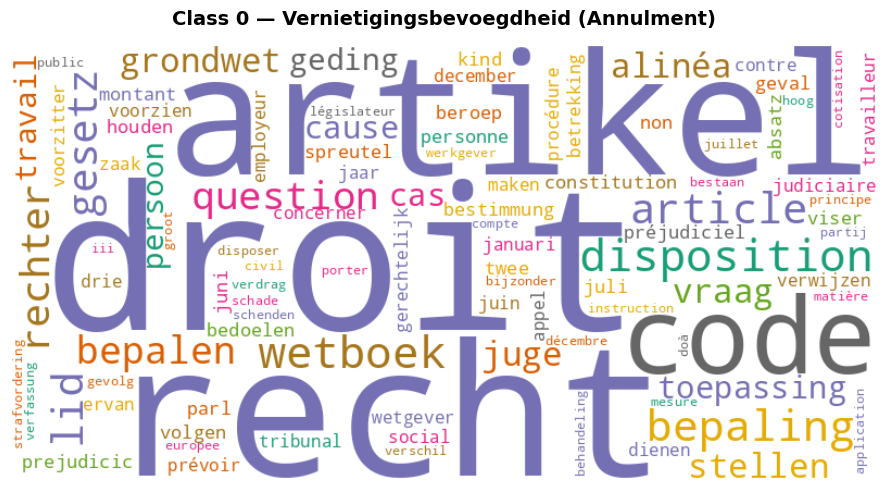

Saved: wordcloud_0.png


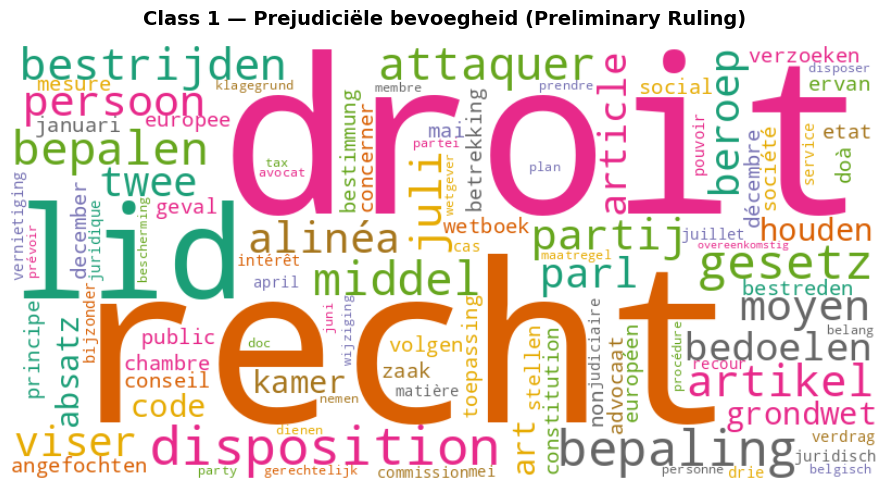

Saved: wordcloud_1.png


In [45]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD
import numpy as np


def generate_wordcloud(df, text_col, label_col, class_value, title):
    text = ' '.join(df[df[label_col] == class_value][text_col].dropna().values)
    
    wc = WordCloud(
        width            = 800,
        height           = 400,
        background_color = 'white',
        max_words        = 100,
        colormap         = 'Dark2',
        collocations     = False     
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(f'wordcloud_{class_value}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: wordcloud_{class_value}.png")

generate_wordcloud(
    df, 
    text_col    = 'content_lemmatized',
    label_col   = 'label',
    class_value = 0,
    title       = 'Class 0 — Vernietigingsbevoegdheid (Annulment)'
)

generate_wordcloud(
    df,
    text_col    = 'content_lemmatized',
    label_col   = 'label',
    class_value = 1,
    title       = 'Class 1 — Prejudiciële bevoegheid (Preliminary Ruling)'
)

In [1]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

texts = df['content_lemmatized'].values
labels = df['keywords'].values

# encode labels
le = LabelEncoder()
y = le.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=y
)

In [51]:
from collections import Counter

def build_vocab(texts, max_vocab=10000):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    
    vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(max_vocab))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

vocab = build_vocab(X_train)

In [52]:
def encode_text(text, vocab, max_len=200):
    tokens = text.split()
    seq = [vocab.get(t, 1) for t in tokens] 
    
    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))   
    else:
        seq = seq[:max_len]
    
    return seq

X_train_seq = [encode_text(t, vocab) for t in X_train]
X_test_seq  = [encode_text(t, vocab) for t in X_test]

In [53]:
import torch
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train_seq, y_train)
test_dataset  = TextDataset(X_test_seq, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [54]:
import torch.nn as nn

class BiGRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        
        self.fc = nn.Linear(hidden_dim * 2, 2)  
    
    def forward(self, x):
        x = self.embedding(x)
        out, h = self.gru(x) 
        
        # concatenate forward + backward
        h = torch.cat((h[-2], h[-1]), dim=1)
        
        out = self.fc(h)
        return out

model = BiGRUModel(len(vocab))

In [56]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 5.6237
Epoch 2, Loss: 4.9697
Epoch 3, Loss: 3.2050
Epoch 4, Loss: 2.3528
Epoch 5, Loss: 1.4811
Epoch 6, Loss: 1.0032
Epoch 7, Loss: 0.7215
Epoch 8, Loss: 0.4040
Epoch 9, Loss: 0.4887
Epoch 10, Loss: 0.2868


In [57]:
from sklearn.metrics import accuracy_score, f1_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds))

Accuracy: 0.6829268292682927
F1 Score: 0.5185185185185185


## Reasons
- data is small
- with small data model may not generalize well
